# Synchronization Analysis With $\tau$-Recurrence Rate And CPR

-- Malte Springer --

**Information**: This notebook contains the code for the analysis of different synchronization phenomena with the $\tau$-recurrence rate and CPR from the paper 'Detecting Synchronization In Time Series Using Recurrence Plots And Recurrence Quantification Analysis'

1. Modules are importet and parameters for the matplotlib visualization are set

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",

    "text.latex.preamble": r"""
        \usepackage{helvet}
        \usepackage{sfmath}
        \renewcommand{\familydefault}{\sfdefault}
    """,

    "axes.formatter.use_mathtext": False,

    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

from scipy.integrate import solve_ivp
from scipy.spatial.distance import pdist, squareform

from tqdm import tqdm

# we can use the pyunicorn classes for all types of recurrence plots for convenience
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot
from pyunicorn.timeseries.cross_recurrence_plot import CrossRecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot

import recurrence

import os
from contextlib import redirect_stdout

np.random.seed(42)

## Simulate The Time Series

2. Time series for the components of each of the dynamical systems for each of the synchronization types (lag, phase, generalized) are produced by defining the model equations and integrating for the same number of time steps.

In [2]:
# Lag Synchronization -- Model was specified by Zinan Lyu --

def coupled_rossler_delay(a=0.2, b=0.2, c=5.7,
                         k=0.5, tau=2.0,
                         dt=0.01, steps=15000):

    delay_steps = int(tau / dt)

    # initialize arrays
    xd = np.zeros(steps)
    yd = np.zeros(steps)
    zd = np.zeros(steps)

    xr = np.zeros(steps)
    yr = np.zeros(steps)
    zr = np.zeros(steps)

    # initial conditions
    xd[0], yd[0], zd[0] = 1, 1, 1
    xr[0], yr[0], zr[0] = 0, 0, 0

    for i in range(steps - 1):

        # drive
        xd[i+1] = xd[i] + dt * (-yd[i] - zd[i])
        yd[i+1] = yd[i] + dt * (xd[i] + a * yd[i])
        zd[i+1] = zd[i] + dt * (b + zd[i] * (xd[i] - c))

        # delayed signal
        if i > delay_steps:
            xd_tau = xd[i - delay_steps]
        else:
            xd_tau = xd[0]

        # response
        xr[i+1] = xr[i] + dt * (-yr[i] - zr[i] + k * (xd_tau - xr[i]))
        yr[i+1] = yr[i] + dt * (xr[i] + a * yr[i])
        zr[i+1] = zr[i] + dt * (b + zr[i] * (xr[i] - c))

    return np.vstack([xd, yd, zd, xr, yr, zr])

k_values = np.linspace(0, 0.3, 50)

results_lag = {}

for k in tqdm(k_values):
    results_lag[k] = coupled_rossler_delay(k=k)

100%|██████████| 50/50 [00:01<00:00, 33.79it/s]


In [3]:
# Phase Synchronization -- Model was specified by Samuel Jaramillo --

def coupled_Roessler(t, X, a, b, c, nu, mu):
    """
    X is a flattened vector [x1, x2, x3, y1, y2, y3].
    x corresponds to the first system, y corresponds to the 
    second one. 
    """
    dX = np.zeros(len(X))

    #First system (A.9)
    dX[0] = -(1 + nu)*X[1] - X[2]
    dX[1] = (1 + nu)*X[0] + a*X[1] + mu*(X[4] - X[1])
    dX[2] = b + X[2]*(X[0] - c)

    #Second system (A.10)
    dX[3] = -(1 - nu)*X[4] - X[5]
    dX[4] = (1 - nu)*X[3] + a*X[4] + mu*(X[1] - X[4])
    dX[5] = b + X[5]*(X[3] - c)

    return dX

#### Parameters ####

a, b, c = 0.16, 0.1, 8.5
nu = 0.02
mu = 0.05

T = 15000*0.02  #
dt = 0.02 #Bigger dt gave too rough of a plot

X0 = np.zeros(6) #np.random.rand(6)

t_span = (0, T)
t_eval = np.arange(0, T, dt)

#### Integration ####

coupling_mu = np.linspace(0,0.12,50) # 0.002

results_phs = {}

for m in tqdm(coupling_mu):
    results_phs[m] = solve_ivp(coupled_Roessler, t_span, X0, t_eval=t_eval, args=(a, b, c, nu, m), method="RK45")

100%|██████████| 50/50 [00:03<00:00, 13.52it/s]


In [4]:
# Generalized Synchronization -- Model was specified by Malte Springer -- 

def coupled_system(t, state, driver="roessler", response="lorenz", 
                   a=0.2, b=0.2, c=5.7,
                   sigma=10, rho=28, beta=8/3, eps=0.1,
                   synch=["x", "y", "z"],
                   g=None):
    '''
    g : Functional Relationship between driver and response system (python function)
    '''

    if g is None:
          def g(x):
                return x

    x1, y1, z1, x2, y2, z2 = state

    if driver == "roessler":
        dx1 = -(y1 + z1)
        dy1 = x1 + a * y1
        dz1 = b + (x1 - c) * z1

        if response == "lorenz":
                dx2 = sigma * (y2 - x2) + eps * g(x1) if "x" in synch else sigma * (y2 - x2) 
                dy2 = x2 * (rho - z2) - y2 + eps * g(y1) if "y" in synch else x2 * (rho - z2) - y2
                dz2 = x2 * y2 - beta * z2 + eps * g(z1) if "z" in synch else x2 * y2 - beta * z2
        elif response == "roessler":
                dx2 = -(y2 + z2) + eps * g(x1) if "x" in synch else -(y2 + z2)
                dy2 = x2 + a * y2 + eps * g(y1) if "y" in synch else x2 + a * y2
                dz2 = b + (x2 - c) * z2 + eps * g(z1) if "z" in synch else b + (x2 - c) * z2
    
    elif driver == "lorenz":
        dx1 = sigma * (y1 - x1)
        dy1 = x1 * (rho - z1) - y1
        dz1 = x1 * y1 - beta * z1

        if response == "lorenz":
                dx2 = sigma * (y2 - x2) + eps * g(x1) if "x" in synch else sigma * (y2 - x2)
                dy2 = x2 * (rho - z2) - y2 + eps * g(y1) if "y" in synch else x2 * (rho - z2) - y2
                dz2 = x2 * y2 - beta * z2 + eps * g(z1) if "z" in synch else x2 * y2 - beta * z2
        elif response == "roessler":
                dx2 = -(y2 + z2) + eps * g(x1) if "x" in synch else -(y2 + z2)
                dy2 = x2 + a * y2 + eps * g(y1) if "y" in synch else x2 + a * y2
                dz2 = b + (x2 - c) * z2 + eps * g(z1) if "z" in synch else b + (x2 - c) * z2


    return [dx1, dy1, dz1, dx2, dy2, dz2]



#### Parameters ####

T = 15000*0.02  #
dt = 0.02

XYZ0 = np.random.rand(6)   

t_span = (0, T)
t_eval = np.arange(0, T, dt)

a, b, c = 0.2, 0.2, 5.7        # Roessler
sigma, rho, beta = 10, 28, 8/3 # Lorenz

driver = "roessler"
response = "lorenz"

synch = ["x"] 

def g(x):
    return x

#### Integration ####

#epss = np.logspace(-2, 3, 50) # 2
epss = np.linspace(0, 50, 50) # 2

results_gen = {}

for e in tqdm(epss):
    results_gen[e] = solve_ivp(
        coupled_system,
        t_span,
        XYZ0,
        t_eval=t_eval,
        args=(driver, response, a, b, c, sigma, rho, beta, e, synch, g),
        method="RK45"
    )

100%|██████████| 50/50 [00:15<00:00,  3.22it/s]


## $\tau$-Recurrence Rate And CPR

In [5]:
def plot_tau(ts1, ts2, res_dict=None, key=None, transient=0, saveas=None, end=-1):
    '''
    Description: Function to plot two vectors which store values of the recurrence rate indexed by tau. 
    
    Inputs:
    ts1, ts2: Time series data for the two systems
        or
    res_dict: Dictionary containing the results of the simulations
    key: Key to access one simulation with specific coupling strength
    transient: Number of initial time steps to discard (transient period)
    saveas: Filename to save the plot (without extension)
    end: Index to limit the time series if the recurrence plot computation takes too long otherwise
    '''
    
    if not any([(res_dict is None), (key is None)]):
        if "Lag" in saveas:
            ts1 = res_dict[key][0:3, transient:end]
            ts2 = res_dict[key][3:6, transient:end]
        else:
            ts1 = res_dict[key].y[0:3, transient:end]
            ts2 = res_dict[key].y[3:6, transient:end]

    # redirect the auto-prints from pyunicorn
    with open(os.devnull, 'w') as f:
        with redirect_stdout(f):
            RX = RecurrencePlot(ts1.T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()
            RY = RecurrencePlot(ts2.T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

    rt1 = recurrence.tau_recurrence(RX)
    rt2 = recurrence.tau_recurrence(RY)

    fig, ax = plt.subplots(figsize=(10,3))
    ax.plot(range(len(rt1)), rt1, color="blue", alpha=0.7, label=r"$RR_{\tau}$-System 1", ls="-")
    ax.plot(range(len(rt2)), rt2, color="red", alpha=0.7, label=r"$RR_{\tau}$-System 2", ls="--")

    leg = plt.legend(facecolor="white", edgecolor="black", loc="center right")
    plt.xlabel(r"Lag $\tau$")
    plt.ylabel(r"$RR_{\tau}$")

    plt.tight_layout()
    plt.savefig(f"{saveas}.pdf", dpi=300)

    plt.show()

In [6]:
# Globally set transient and end indices to select time series of the same length

transient = 5000
end = 10000

### Tests For Lag Synchronization

In [7]:
cprs_lag = []

for i, k in enumerate(k_values):
    sol_c = results_lag[k]

    with open(os.devnull, 'w') as f:
        with redirect_stdout(f):
            RX = RecurrencePlot(sol_c[0:3, transient:end].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()
            RY = RecurrencePlot(sol_c[3:6, transient:end].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

    CPR = recurrence.cpr(RX, RY)

    cprs_lag.append(CPR)

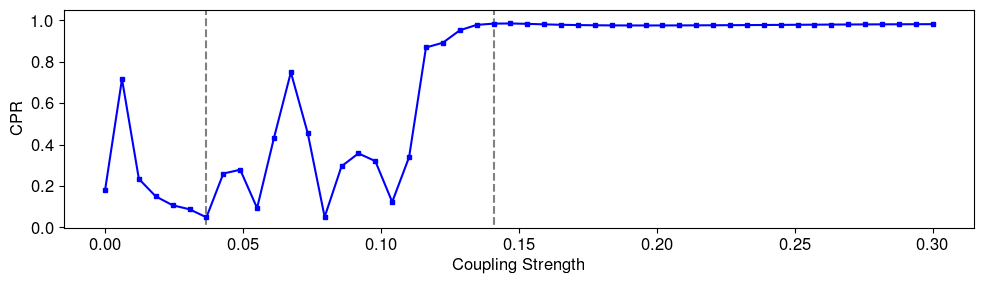

In [8]:
c1 = k_values[6]
c2 = k_values[23]

plt.figure(figsize=(10,3))
plt.vlines(c1, -0.2, 1.2, color="grey", ls="--")
plt.vlines(c2, -0.2, 1.2, color="grey", ls="--")
plt.plot(k_values, cprs_lag, color="blue", marker="s", markersize=3)
plt.xlabel("Coupling Strength")
plt.ylabel("CPR")
plt.ylim(np.min(cprs_lag)-0.05, 1.0+0.05)
plt.tight_layout()
plt.savefig("Lag_CPR_Eps.pdf", dpi=300)
plt.show()

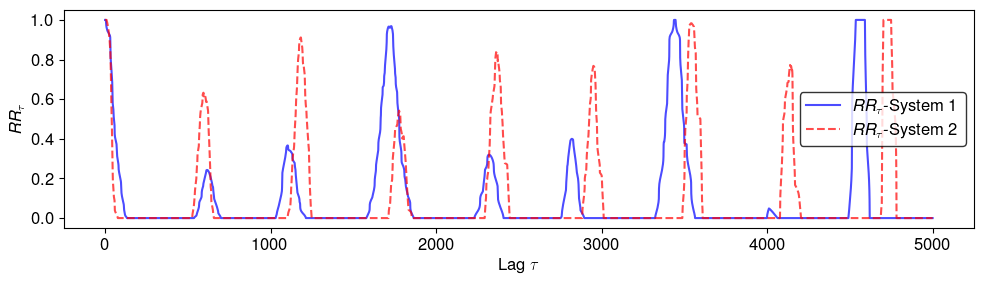

In [9]:
plot_tau(None, None, res_dict=results_lag, key=list(results_lag.keys())[6], transient=5000, saveas="Lag_No_Synch_tau", end=end)

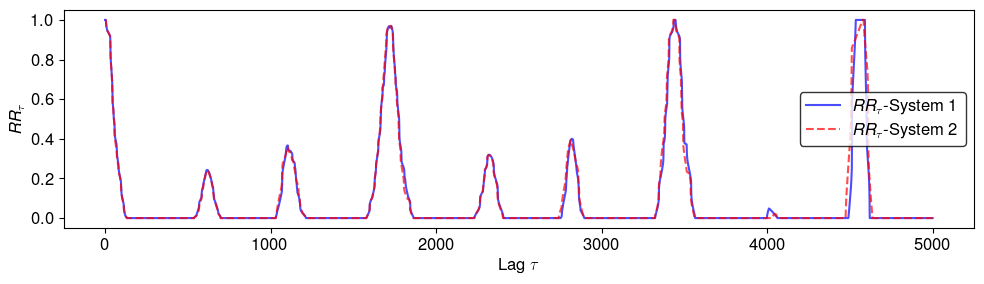

In [10]:
plot_tau(None, None, res_dict=results_lag, key=list(results_lag.keys())[23], transient=5000, saveas="Lag_Synch_tau", end=end)

### Tests For Phase Synchronization

In [11]:
cprs_phs = []

for i, mu in enumerate(coupling_mu):
    sol_c = results_phs[mu]

    with open(os.devnull, 'w') as f:
        with redirect_stdout(f):
            RX = RecurrencePlot(sol_c.y[0:3, transient:end].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()
            RY = RecurrencePlot(sol_c.y[3:6, transient:end].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

    CPR = recurrence.cpr(RX, RY)

    cprs_phs.append(CPR)

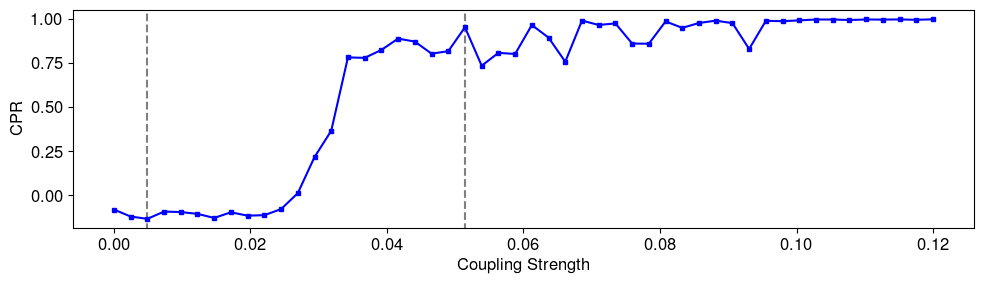

In [12]:
c1 = coupling_mu[2]
c2 = coupling_mu[21]

plt.figure(figsize=(10,3))
plt.vlines(c1, -0.2, 1.2, color="grey", ls="--")
plt.vlines(c2, -0.2, 1.2, color="grey", ls="--")
plt.plot(coupling_mu, cprs_phs, color="blue", marker="s", markersize=3)
plt.xlabel("Coupling Strength")
plt.ylabel("CPR")
plt.ylim(np.min(cprs_phs)-0.05, 1.0+0.05)
plt.tight_layout()
plt.savefig("Phase_CPR_Eps.pdf", dpi=300)
plt.show()

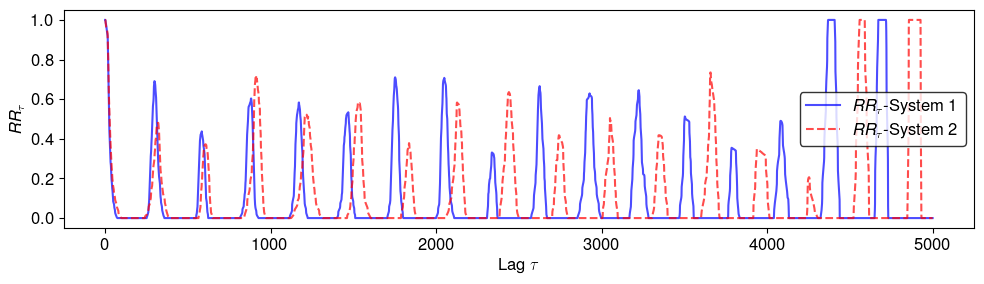

In [13]:
plot_tau(None, None, res_dict=results_phs, key=list(results_phs.keys())[2], transient=5000, saveas="Phase_No_Synch_tau", end=end)

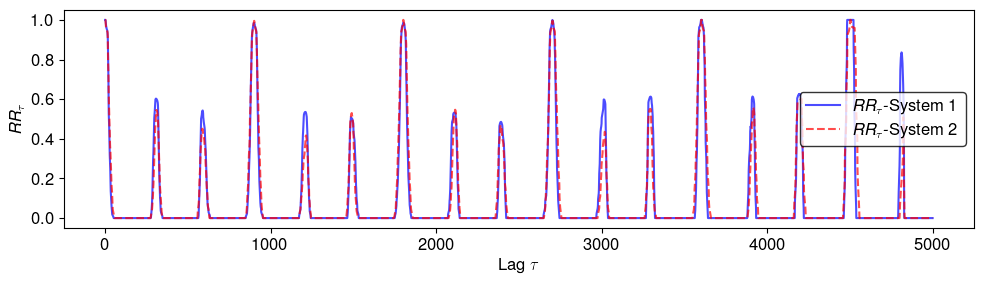

In [14]:
plot_tau(None, None, res_dict=results_phs, key=list(results_phs.keys())[21], transient=5000, saveas="Phase_Synch_tau", end=end)

### Tests For Generalized Synchronization

In [15]:
cprs_gen = []

for i, e in enumerate(epss):
    sol_c = results_gen[e]

    with open(os.devnull, 'w') as f:
        with redirect_stdout(f):
            RX = RecurrencePlot(sol_c.y[0:3, transient:end].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()
            RY = RecurrencePlot(sol_c.y[3:6, transient:end].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

    CPR = recurrence.cpr(RX, RY)

    cprs_gen.append(CPR)

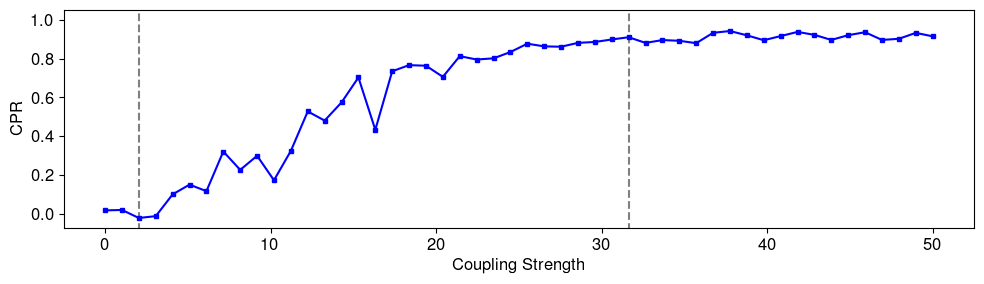

In [16]:
c1 = epss[2]
c2 = epss[31]

plt.figure(figsize=(10,3))
plt.vlines(c1, -0.2, 1.2, color="grey", ls="--")
plt.vlines(c2, -0.2, 1.2, color="grey", ls="--")
plt.plot(epss, cprs_gen, color="blue", marker="s", markersize=3)
plt.xlabel("Coupling Strength")
plt.ylabel("CPR")
plt.ylim(np.min(cprs_gen)-0.05, 1.0+0.05)
plt.tight_layout()
plt.savefig("Gen_CPR_Eps.pdf", dpi=300)
plt.show()

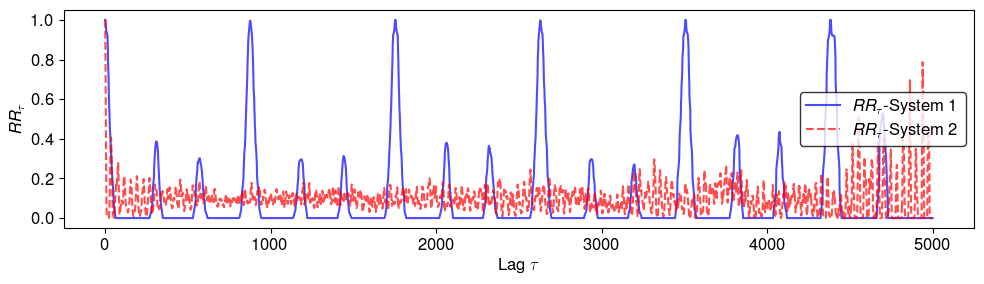

In [17]:
plot_tau(None, None, res_dict=results_gen, key=list(results_gen.keys())[2], transient=transient, saveas="Gen_No_Synch_tau", end=end)

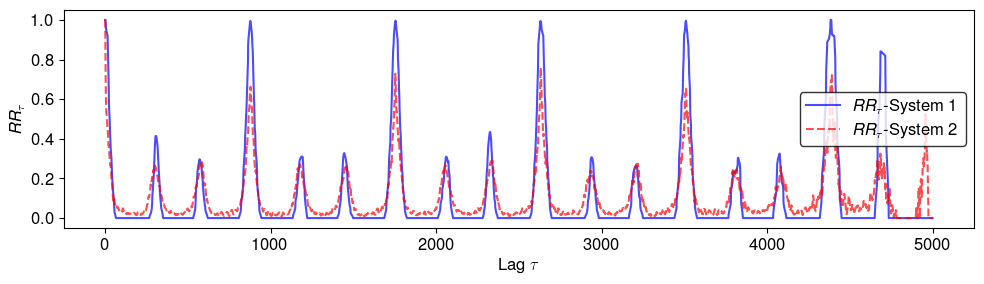

In [18]:
plot_tau(None, None, res_dict=results_gen, key=list(results_gen.keys())[31], transient=transient, saveas="Gen_Synch_tau", end=end)

### Test For Problematic Mapping Function

In [19]:
#### Parameters ####

T = 15000*0.02  #
dt = 0.02

XYZ0 = np.random.rand(6)   

t_span = (0, T)
t_eval = np.arange(0, T, dt)

a, b, c = 0.2, 0.2, 5.7        # Roessler
sigma, rho, beta = 10, 28, 8/3 # Lorenz

driver = "roessler"
response = "lorenz"

synch = ["x"] 

def g_t(x):
    return np.abs(x)

#### Integration ####

#epss = np.logspace(-2, 3, 50) # 2
epss = np.linspace(0, 50, 50) # 2

results_gen_t = {}

for e in tqdm(epss):
    results_gen_t[e] = solve_ivp(
        coupled_system,
        t_span,
        XYZ0,
        t_eval=t_eval,
        args=(driver, response, a, b, c, sigma, rho, beta, e, synch, g_t),
        method="RK45"
    )

100%|██████████| 50/50 [00:30<00:00,  1.66it/s]


In [20]:
cprs_gen_t = []

for i, e in enumerate(epss):
    sol_c = results_gen_t[e]

    with open(os.devnull, 'w') as f:
        with redirect_stdout(f):
            RX = RecurrencePlot(sol_c.y[0:3, transient:end].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()
            RY = RecurrencePlot(sol_c.y[3:6, transient:end].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

    CPR = recurrence.cpr(RX, RY)

    cprs_gen_t.append(CPR)

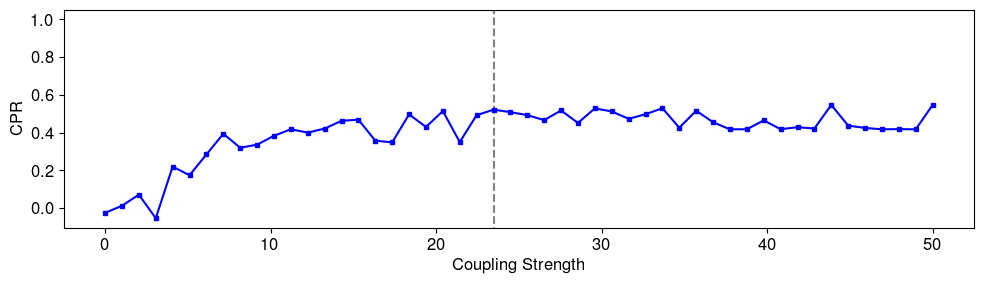

In [21]:
c2 = epss[23]

plt.figure(figsize=(10,3))
plt.vlines(c2, -0.2, 1.2, color="grey", ls="--")
plt.plot(epss, cprs_gen_t, color="blue", marker="s", markersize=3)
plt.xlabel("Coupling Strength")
plt.ylabel("CPR")
plt.ylim(np.min(cprs_gen_t)-0.05, 1.0+0.05)
plt.tight_layout()
plt.savefig("Gen_CPR_Eps_t.pdf", dpi=300)
plt.show()

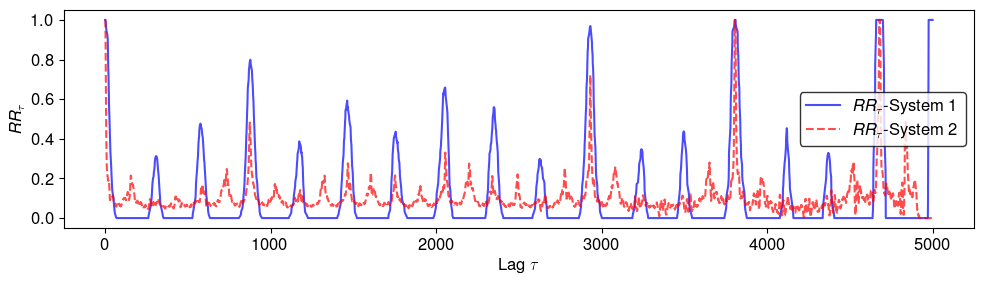

In [22]:
plot_tau(None, None, res_dict=results_gen_t, key=list(results_gen_t.keys())[23], transient=transient, saveas="Gen_Synch_tau_t", end=end)

## Recurrence Plot Size Sensitivity Test

In [25]:
sol_tau = results_phs[coupling_mu[21]]

with open(os.devnull, 'w') as f:
            with redirect_stdout(f):
                glob_thrsh_x = np.percentile(RecurrencePlot(sol_tau.y[0:3, transient:].T, metric="euclidean", recurrence_rate=0.1).distance_matrix(metric="euclidean"), 10)
                glob_thrsh_y = np.percentile(RecurrencePlot(sol_tau.y[3:6, transient:].T, metric="euclidean", recurrence_rate=0.1).distance_matrix(metric="euclidean"), 10)

sizes = list(range(10, 10000, 20))
cprs_t = []

for s in sizes:
    vals = []
    for start in range(transient, 12000, s):

        with open(os.devnull, 'w') as f:
            with redirect_stdout(f):
                RX = RecurrencePlot(sol_tau.y[0:3, start:start+s].T, metric="euclidean", threshold=glob_thrsh_x).recurrence_matrix()
                RY = RecurrencePlot(sol_tau.y[3:6, start:start+s].T, metric="euclidean", threshold=glob_thrsh_x).recurrence_matrix()

        CPR = recurrence.cpr(RX, RY)
        vals.append(CPR)
    
    mean = np.mean(vals) if np.mean(vals) is not None else 0
    cprs_t.append(mean)

c:\Users\MS\OneDrive\Studium\Master\RSgIV_Sem_3\Nonlinear_Data_Analysis\Project\project_code\analysis-scripts\recurrence.py:885: RuntimeWarning: invalid value encountered in divide
  qx_ = (qx_ - np.nanmean(qx_)) / np.nanstd(qx_)
c:\Users\MS\OneDrive\Studium\Master\RSgIV_Sem_3\Nonlinear_Data_Analysis\Project\project_code\analysis-scripts\recurrence.py:887: RuntimeWarning: invalid value encountered in divide
  qy_ = (qy_ - np.nanmean(qy_)) / np.nanstd(qy_)


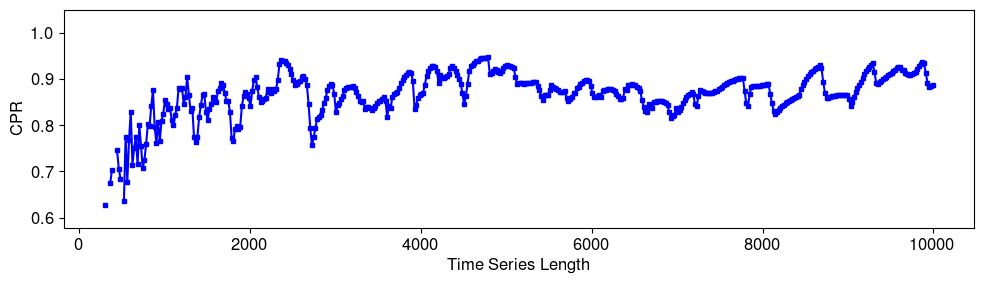

In [26]:
plt.figure(figsize=(10,3))
plt.plot(sizes, cprs_t, color="blue", marker="s", markersize=3)
plt.xlabel("Time Series Length")
plt.ylabel("CPR")
plt.ylim(np.nanmin(cprs_t)-0.05, 1.0+0.05)
plt.tight_layout()
plt.savefig("Size_Dep_t.pdf", dpi=300)
plt.show()